In [1]:
import pandas as pd

data = {
    "character": ["Daemon", "Rhaenyra", "Aemond", "Alicent"],
    "mentions": [1500, 1800, 1200, 900]
}

df = pd.DataFrame(data)

df

,character,mentions
0,Daemon,1500
1,Rhaenyra,1800
2,Aemond,1200
3,Alicent,900


In [2]:
import plotly.express as px

fig = px.bar(
    df,
    x="character",
    y="mentions",
    title="House of the Dragon Character Mentions"
)

fig.show()

In [3]:
import pandas as pd

relationships = pd.DataFrame({
    "source": [
        "Daemon",
        "Daemon",
        "Rhaenyra",
        "Aemond",
        "Alicent"
    ],
    "target": [
        "Rhaenyra",
        "Caraxes",
        "Syrax",
        "Vhagar",
        "Aegon"
    ]
})

relationships

,source,target
0,Daemon,Rhaenyra
1,Daemon,Caraxes
2,Rhaenyra,Syrax
3,Aemond,Vhagar
4,Alicent,Aegon


Matplotlib is building the font cache; this may take a moment.


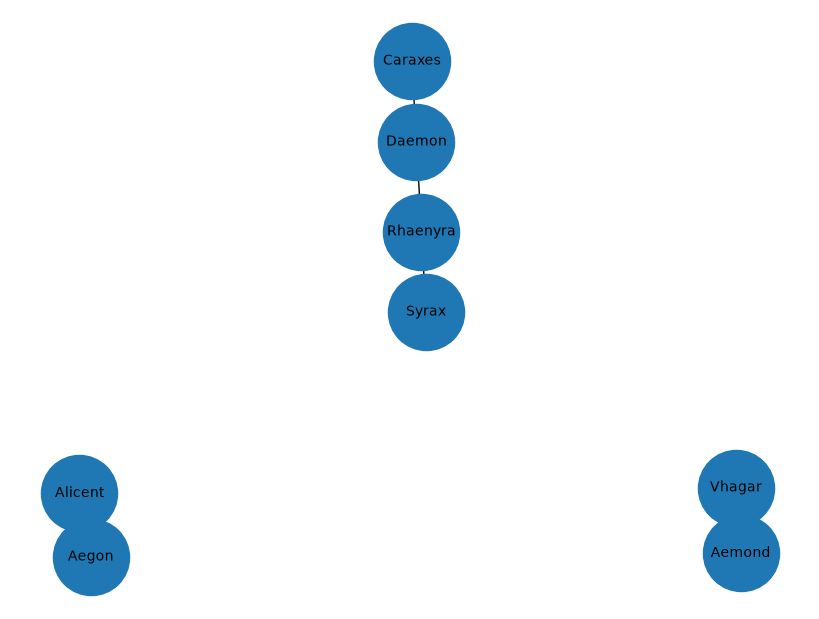

In [4]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.from_pandas_edgelist(
    relationships,
    source="source",
    target="target"
)

plt.figure(figsize=(8,6))

nx.draw(
    G,
    with_labels=True,
    node_size=3000,
    font_size=10
)

plt.show()

In [7]:
import pandas as pd

df = pd.read_csv("../data/hotd_comments.csv")

df.head()

,video_url,comment
0,https://www.youtube.com/watch?v=KmfX6RE2WAQ,Get a free audiobook with an Audible trial: ht...
1,https://www.youtube.com/watch?v=KmfX6RE2WAQ,Am I crazy to think that Rhyneara maybe sees A...
2,https://www.youtube.com/watch?v=KmfX6RE2WAQ,Always gotta race swap
3,https://www.youtube.com/watch?v=KmfX6RE2WAQ,"""HOT D"" 😂"
4,https://www.youtube.com/watch?v=KmfX6RE2WAQ,I think they have to soft reboo the main show ...


In [8]:
df["comment"].sample(20).tolist()

['I don’t think misaria’s past relationship with Daemon will be a problem between the 2 women. Both of them see him for what he is now.',
 'crazy to think that the dragons would never go extinct if viserys wasn’t named heir',
 'They\'ve always said the secret to making Valyrian steel was lost to the ages, right? But what if it wasn\'t? What if the key to making Valyrian steel is hidden in the story of Azor Ahai and Nissa Nissa? What if a blood sacrifice was required for every Valyrian steel weapon to be forged? Fire and blood are a part of so many Targaryen traditions. We still don\'t know how the "Catspaw" dagger was made, who forged it, etc. Maybe they put so much focus on it because we\'ll eventually learn that info from this series.',
 "I can't believe how botched this season has been. They completely ruined Rhaenyra and Alicent's characters. Rhaneyra should've been ready for blood after her son's death. Allicent hates her children, the whole reason for the war starting. The drop o

In [9]:
characters = [
    "Daemon",
    "Rhaenyra",
    "Alicent",
    "Aemond",
    "Aegon",
    "Viserys",
    "Otto",
    "Criston",
    "Corlys",
    "Rhaenys",
    "Jace",
    "Jacaerys",
    "Luke",
    "Lucerys",
    "Baela",
    "Rhaena",
    "Helaena",
    "Larys",
    "Mysaria",
    "Harwin",
    "Vhagar",
    "Caraxes",
    "Syrax",
    "Sunfyre",
    "Arrax"
]

In [10]:
from collections import Counter

mention_counts = Counter()

for comment in df["comment"].astype(str):

    comment_lower = comment.lower()

    for character in characters:

        if character.lower() in comment_lower:
            mention_counts[character] += 1

mention_counts

Counter({'Daemon': 361,
         'Rhaenyra': 361,
         'Alicent': 283,
         'Aegon': 260,
         'Viserys': 223,
         'Aemond': 214,
         'Criston': 125,
         'Otto': 106,
         'Rhaenys': 88,
         'Larys': 86,
         'Jace': 55,
         'Vhagar': 45,
         'Helaena': 42,
         'Corlys': 37,
         'Luke': 35,
         'Mysaria': 34,
         'Rhaena': 28,
         'Harwin': 19,
         'Baela': 14,
         'Caraxes': 11,
         'Sunfyre': 11,
         'Syrax': 7,
         'Jacaerys': 7,
         'Lucerys': 6,
         'Arrax': 2})

In [11]:
mentions_df = (
    pd.DataFrame(
        mention_counts.items(),
        columns=["Character", "Mentions"]
    )
    .sort_values("Mentions", ascending=False)
)

mentions_df.head(10)

,Character,Mentions
2,Daemon,361
3,Rhaenyra,361
0,Alicent,283
1,Aegon,260
4,Viserys,223
8,Aemond,214
6,Criston,125
5,Otto,106
7,Rhaenys,88
16,Larys,86


In [12]:
daemon_comments = df[
    df["comment"].str.contains(
        "Daemon",
        case=False,
        na=False
    )
]

print("Total Daemon comments:", len(daemon_comments))

daemon_comments["comment"].sample(20).tolist()

Total Daemon comments: 361


["18:52 That's still not true. Rhaena and Baela are Targaryens by their father Daemon, and the Strong boys are... not Velaryons at all. So I mean, considering inheritance, main bloodline and House name goes through the male line, well, Vaemond wasn't lying here. The main Velaryon line would no longer be on the Driftwood Throne, it would be the Seed of House Strong, instead.\n\nYes, there is SOME Velaryon blood involved, but for all intents and purposes, it would House Strong and Targaryen coming together, under mainly the Strong's bloodline, next to nothing to do with House Velaryon.",
 'Daemon is not comfortable having sex. It is different from erectile dysfunction. Is Alicent having hormonal dysfunction when she has sex with Viserys? Sometimes you just focus on something simple to make the script work.',
 'Could be that when the witch says to Daemon “you will die in this place” she means metaphorically, i.e. the daemon that arrived at harrenhal will not be the same as the one that le

In [13]:
daemon_rhaenyra = df[
    df["comment"].str.contains("Daemon", case=False, na=False)
    &
    df["comment"].str.contains("Rhaenyra", case=False, na=False)
]

len(daemon_rhaenyra)

87

In [14]:
daemon_rhaenyra["comment"].sample(10).tolist()

["\xa0@thisguy8106\xa0 It has nothing to do with it. Viserys knew that Rhaenyra's claim could be challenged just because she is a woman. Women in that time were considered weak, and if you show weakness one of the other royals would challenge or rebel against the crown. If Daemon had been heir none of the houses would dare rebel against him, he would've been a bad king, but he wouldn't cause the damage the civil war caused.\nIn some things in life all that matters are results. It doesn't matter what you perceive as right or wrong or what you think is just.\nWith Rhaenyra as heir you got a bloody civil war, the ending of dragons and the ending of the second biggest house in Westeros. She also managed to cause more damage to house Targaryen than Robert and Ned did.\nJaeherys  had the same thoughts and gave the crown to Viserys instead of Rhaenys, when she would've been a far better leader and ruler than him. Had he chosen Rhaenys as heir,  there was a big chance someone would challenge h

In [15]:
daemon_comments = df[
    df["comment"].str.contains("Daemon", case=False, na=False)
]

daemon_comments.shape

(361, 2)

In [16]:
for comment in daemon_comments["comment"].head(3):
    print(comment)
    print("-" * 80)

I really liked the episode, but there was one element that jar'd me out the narrative for 10minutes or more, it was so dumb to me. But no one is noticing it. However you mentioning Daemons behaviour comes closest so let me write it out here.

Doesn't anyone have a problem with how Daemon cheated in the joust? I mean he pretty much stopped just short of skewering his opponents horse with the lance? and he did it in such obvious purposeful fashion? Lets set aside for the moment how EXPENSIVE trained warhorses were in medieval times, how are there no consequences for that reckless and obviously unchivalrous cheating? 

If there are no consequences for such reckless action that could EASILY result in the DEATH of noble families SONS (which they LOVE and strive to have above all), why would any of them joust? why would any of them bother showing up for a contest of "skill" if reckless cheating is allowed? why would they even bother to accept ANY of a cheaters challenges. And when they refus

In [17]:
from collections import Counter

associated_characters = Counter()

for comment in daemon_comments["comment"].astype(str):

    comment_lower = comment.lower()

    for character in characters:

        if character != "Daemon" and character.lower() in comment_lower:
            associated_characters[character] += 1

associated_characters.most_common(10)

[('Rhaenyra', 87),
 ('Aemond', 53),
 ('Viserys', 43),
 ('Alicent', 30),
 ('Aegon', 25),
 ('Otto', 21),
 ('Rhaenys', 13),
 ('Criston', 11),
 ('Rhaena', 10),
 ('Mysaria', 10)]

In [18]:
import pandas as pd

daemon_network = pd.DataFrame(
    associated_characters.items(),
    columns=["Character", "Connections"]
)

daemon_network = daemon_network.sort_values(
    by="Connections",
    ascending=False
)

daemon_network

,Character,Connections
0,Rhaenyra,87
8,Aemond,53
2,Viserys,43
7,Alicent,30
3,Aegon,25
1,Otto,21
4,Rhaenys,13
9,Criston,11
5,Rhaena,10
11,Mysaria,10


In [19]:
daemon_text = " ".join(
    daemon_comments["comment"].astype(str)
)

len(daemon_text)

110866

In [20]:
from collections import Counter
import re

words = re.findall(r"\b[a-zA-Z]{4,}\b", daemon_text.lower())

word_counts = Counter(words)

word_counts.most_common(30)

[('daemon', 443),
 ('that', 303),
 ('with', 146),
 ('rhaenyra', 126),
 ('like', 120),
 ('have', 115),
 ('they', 113),
 ('this', 113),
 ('would', 102),
 ('when', 96),
 ('just', 91),
 ('about', 78),
 ('because', 58),
 ('more', 57),
 ('viserys', 56),
 ('what', 55),
 ('there', 53),
 ('from', 53),
 ('think', 53),
 ('their', 52),
 ('than', 49),
 ('show', 49),
 ('alicent', 48),
 ('really', 46),
 ('king', 45),
 ('even', 44),
 ('aemond', 43),
 ('also', 41),
 ('been', 40),
 ('episode', 39)]

In [23]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

filtered_words = [
    word
    for word in words
    if word not in ENGLISH_STOP_WORDS
]

filtered_counts = Counter(filtered_words)

filtered_counts.most_common(30)

[('daemon', 443),
 ('rhaenyra', 126),
 ('like', 120),
 ('just', 91),
 ('viserys', 56),
 ('think', 53),
 ('alicent', 48),
 ('really', 46),
 ('king', 45),
 ('aemond', 43),
 ('episode', 39),
 ('didn', 35),
 ('dragon', 35),
 ('people', 35),
 ('time', 33),
 ('know', 31),
 ('aegon', 31),
 ('love', 29),
 ('otto', 29),
 ('throne', 29),
 ('doesn', 28),
 ('good', 28),
 ('dragons', 26),
 ('heir', 24),
 ('look', 24),
 ('wife', 23),
 ('blood', 23),
 ('make', 23),
 ('actually', 23),
 ('scene', 22)]

In [24]:
daemon_comments["comment"].str.len().describe()

count     361.000000
mean      306.110803
std       344.416381
min         6.000000
25%        94.000000
50%       186.000000
75%       403.000000
max      2570.000000
Name: comment, dtype: float64

In [25]:
import nltk

print("NLTK Ready")

NLTK Ready


In [26]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(
    stop_words="english",
    ngram_range=(2, 2),
    max_features=20
)

X = vectorizer.fit_transform(
    daemon_comments["comment"].astype(str)
)

phrases = vectorizer.get_feature_names_out()

counts = X.sum(axis=0).A1

phrase_df = pd.DataFrame({
    "Phrase": phrases,
    "Count": counts
}).sort_values(
    "Count",
    ascending=False
)

phrase_df

,Phrase,Count
14,rhaenyra daemon,11
12,like daemon,10
6,daemon rhaenyra,9
4,daemon just,9
17,twice eyes,8
10,feel like,7
8,don know,7
1,daemon daemon,6
11,killed vaemond,6
3,daemon didn,6


In [27]:
import pandas as pd

relationships = pd.read_csv("../data/character_relationships.csv")

print(relationships.shape)

relationships.head()

(1564, 2)


,source,target
0,Daemon,Rhaenyra
1,Rhaenyra,Alicent
2,Rhaenyra,Otto
3,Alicent,Otto
4,Alicent,Criston


In [28]:
relationship_strength = (
    relationships
    .groupby(["source", "target"])
    .size()
    .reset_index(name="strength")
)

relationship_strength = relationship_strength.sort_values(
    "strength",
    ascending=False
)

relationship_strength.head(20)

,source,target,strength
152,Rhaenyra,Alicent,95
96,Daemon,Rhaenyra,87
81,Daemon,Aemond,53
171,Rhaenyra,Viserys,52
150,Rhaenyra,Aegon,50
57,Alicent,Viserys,46
17,Aemond,Aegon,46
101,Daemon,Viserys,43
38,Alicent,Aegon,42
44,Alicent,Criston,34


In [29]:
import plotly.express as px

top_relationships = relationship_strength.head(15)

fig = px.bar(
    top_relationships,
    x="strength",
    y=top_relationships.apply(
        lambda row: f"{row['source']} ↔ {row['target']}",
        axis=1
    ),
    orientation="h",
    title="Strongest Character Relationships in HOTD Discussions"
)

fig.update_layout(
    height=700
)

fig.show()

In [30]:
character_name = "Daemon"

character_comments = df[
    df["comment"].str.contains(
        character_name,
        case=False,
        na=False
    )
]

character_comments[["comment"]].head(10)

,comment
20,"I really liked the episode, but there was one ..."
23,"Sam duty is different from delight, he clearl..."
29,Sam Alt X didn't say he thinks it's wrong. h...
112,"Daemon's ""Heir for a day"" speech wasn't shown,..."
118,Daemon makes Viserys reign worse with every br...
169,12:24 Wait Daemon gelds rapists? ... Okay I ki...
173,Two corrections. First the choice that Visery...
183,I hate how everyone calls her Emma. It’s Aemma...
264,"At 12:32 there is an error in caption, should ..."
271,Just a heads up that the subtitle in 12:30 inc...


In [31]:
character_name = "Daemon"

character_comments = df[
    df["comment"].str.contains(
        character_name,
        case=False,
        na=False
    )
]

character_comments["length"] = (
    character_comments["comment"]
    .astype(str)
    .str.len()
)

character_comments[
    ["comment", "length"]
].sort_values(
    "length",
    ascending=False
).head(10)

,comment,length
3499,The Burning Mill cut scene was immaculate & go...,2570
2130,"Lastly, I enjoyed the portrayal of Viserys's d...",2267
1902,"""The few times they tried""\nTranslation: R mad...",2240
20,"I really liked the episode, but there was one ...",1868
788,Some of this episode makes no sense.\n\nThe wa...,1758
2181,This episode exposed for me just how bad and u...,1659
2650,"Frankly, Allicent is still the furthest thing ...",1402
1912,@12:46: I agree about it being a dick move on ...,1316
1437,I don't know why I'm wasting my time saying th...,1194
1662,"Alicent is not comparable to Ned, she tries to...",1165


In [32]:
top_daemon_comments = (
    character_comments
    .sort_values("length", ascending=False)
    .head(5)
)

for i, comment in enumerate(top_daemon_comments["comment"], start=1):
    print(f"\nCOMMENT {i}")
    print("-" * 50)
    print(comment[:1000])


COMMENT 1
--------------------------------------------------
The Burning Mill cut scene was immaculate & got the point across about the brutality of war...Feast for Crows. It was also baiting & switching the audience for the actual battle next episode. GoT did it constantly in s2 before Blackwater. Overloading with battles takes away the novelty. Let the casuals who complained about it stick to their mindless action flicks. Meanwhile targ stans mad about Ulf & Baelon? Oh no, a royal prince sired a bastard & water is wet! Where did they think those dragonseeds came from? Look at the timeline even in the book & it's clear some rather recent Targaryen in KL was fooling around. Helaena's "I forgive you" is a prophetic present tense literary device. She's talking about something that hasn't happened yet...the window. Brilliant writing! Finally a depiction of Harrenhal that actually gives it the look & feel of a cursed, haunted castle. The weirdwood reaching out to the Isle of Faces, yearni

In [33]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer(
    "all-MiniLM-L6-v2"
)

print("Model Loaded")

[transformers] Disabling PyTorch because PyTorch >= 2.4 is required but found 2.2.2
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.

A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.5.0 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/Pratyush/HOTD_Observatory/venv/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/Pratyush/HOTD_Observatory/venv/lib/pyt

NameError: name 'nn' is not defined

In [34]:
from sklearn.feature_extraction.text import TfidfVectorizer

daemon_comments_text = " ".join(
    daemon_comments["comment"].astype(str)
)

vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=30
)

X = vectorizer.fit_transform([daemon_comments_text])

keywords = vectorizer.get_feature_names_out()

keywords

array(['aegon', 'aemond', 'alicent', 'daemon', 'did', 'didn', 'doesn',
       'don', 'dragon', 'dragons', 'episode', 'good', 'got', 'heir',
       'just', 'king', 'know', 'like', 'love', 'otto', 'people', 'really',
       'rhaenyra', 'son', 'think', 'throne', 'time', 'viserys', 'war',
       'way'], dtype=object)